# 캘리포니아 집 값 데이터

> 집 값(median_house_value)을 예측하세요. => 회귀문제다 !

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

In [64]:
housing = pd.read_csv('data/housing.csv')

In [65]:
print("\n데이터 정보:")
print(housing.info())
print("\n데이터 통계:")
print(housing.describe())


데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

데이터 통계:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.00

In [66]:
print("\n결측치:")
print(housing.isnull().sum())


결측치:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_24248\1035348893.py:19: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\user\AppData\Local\Programs\Python\Python39\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
C:\Users\user\AppData\Local\Programs\Python\Python39\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


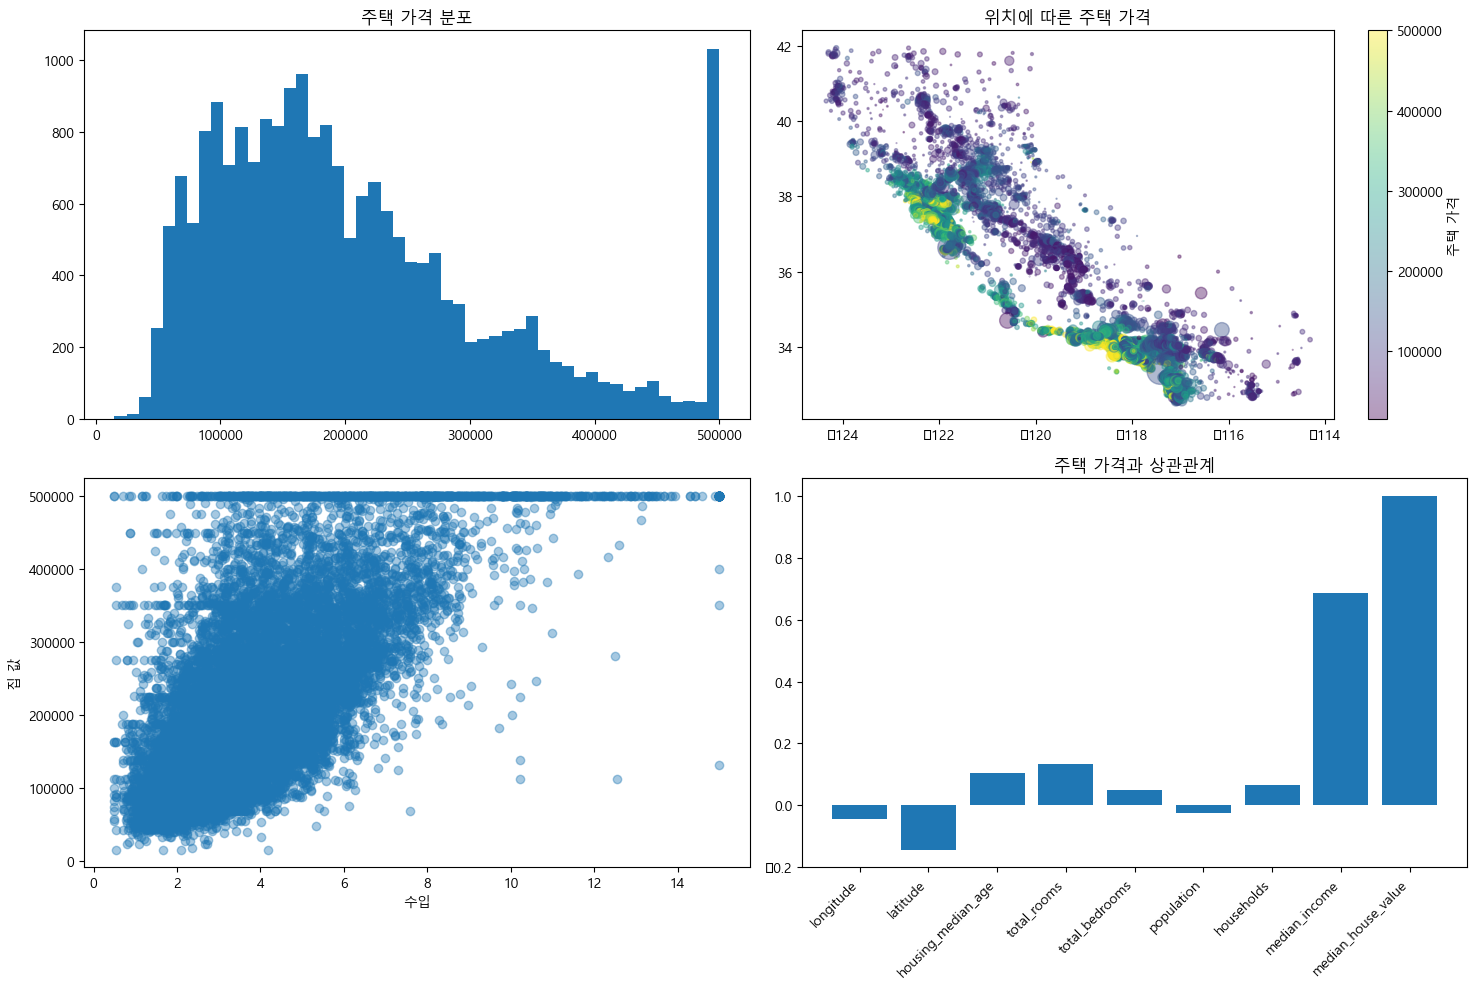

In [67]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
plt.hist(housing["median_house_value"], bins=50)
plt.title("주택 가격 분포")
plt.subplot(2,2,2)
plt.scatter(housing["longitude"], housing["latitude"], alpha=0.4, s=housing["population"]/100, c=housing["median_house_value"], cmap='viridis')
plt.colorbar(label="주택 가격")
plt.title("위치에 따른 주택 가격")
plt.subplot(2,2,3)
plt.scatter(housing["median_income"], housing["median_house_value"], alpha=0.4)
plt.xlabel("수입")
plt.ylabel("집 값")

corr = housing.corr(numeric_only=True)
plt.subplot(2,2,4)
plt.bar(corr["median_house_value"].index, corr["median_house_value"].values)
plt.title("주택 가격과 상관관계")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [68]:
X = housing.drop("median_house_value", axis=1) # 답안 뺸 거
y = housing["median_house_value"]

In [69]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [70]:
numerical_feat = X.select_dtypes(include=["int64", "float64"]).columns # "float64"으로 바꾸는 게 좋음
categorical_feat = ["ocean_proximity"]

In [71]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [72]:
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())])
numerical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [73]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown="ignore")) # 원핫 매개변수 신경쓰기
])
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [74]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(transformers=[('num', numerical_transformer, numerical_feat),
                                ('cat', categorical_transformer, categorical_feat)])
preprocessor # 이 형태로 실행

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['ocean_proximity'])])

In [75]:
from sklearn.linear_model import LinearRegression
linear_model = Pipeline(
    [('preprocessor', preprocessor),
    ('regressor', LinearRegression())]
)
linear_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['ocean_proximity'])])),
                ('regressor', LinearRegression())])

In [76]:
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)
linear_predictions

array([ 54811.88242313, 123864.33890936, 252845.43705076, ...,
       140614.11326652, 243327.82857325, 350156.23528829])